# Project 4: Recruiting vs. Performance

**Question:** Does LSU's elite recruiting translate into on-field performance? Which recruiting classes, position groups, and talent metrics best predict future success — and how much of the gap between input talent and output performance is attributable to coaching?

Projects 2 and 3 established that LSU recruits at an elite level regardless of coaching era (consistently top-10), yet performance varies dramatically. This notebook formalizes that observation with regression models, lagged recruiting-to-performance correlations, position-group analysis, and transfer portal impact.

The fixed income parallel: recruiting is like sourcing deal flow — the raw material of future returns. Talent composite is the portfolio's credit quality. Returning production is the carry from last period. And MOE (from Project 3) is the alpha — the risk-adjusted return that separates good portfolio management from simply owning good assets.

## Setup

### What This Code Does

Loads all libraries including `sklearn.linear_model.LinearRegression` for the regression models. Uses an extended recruiting window (2012–2025) to allow for lagged analysis — since today's on-field performance is driven by recruiting classes from 2-4 years ago, we need data going back further than the 2015 game data.

In [1]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats as sp_stats
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# --- CONFIG ---
API_KEY = os.environ["CFBD_API_KEY"]
TEAM = "LSU"
YEARS = range(2015, 2026)
RECRUIT_YEARS = range(2012, 2026)  # Wider window for lagged analysis

BASE_URL = "https://api.collegefootballdata.com"
HEADERS = {
    "Authorization": f"Bearer {API_KEY}",
    "Accept": "application/json",
}

def cfbd_get(endpoint: str, params: dict = None) -> list[dict]:
    url = f"{BASE_URL}{endpoint}"
    resp = requests.get(url, headers=HEADERS, params=params)
    resp.raise_for_status()
    return resp.json()

LSU_PURPLE = "#461D7C"
LSU_GOLD = "#FDD023"
ERA_COLORS = {"Miles": "#C4A42E", "Orgeron": LSU_PURPLE, "Kelly": "#1B9E77"}

ERA_MAP = {
    2015: "Miles", 2016: "Orgeron", 2017: "Orgeron", 2018: "Orgeron",
    2019: "Orgeron", 2020: "Orgeron", 2021: "Orgeron",
    2022: "Kelly", 2023: "Kelly", 2024: "Kelly", 2025: "Kelly",
}

print("Setup complete.")

Setup complete.


## 1. Pull Recruiting, Talent & Performance Data

### What This Code Does

Pulls four datasets that form the foundation of this analysis:
1. **Recruiting class rankings** (2012–2025) — wider window than previous notebooks because today's performance is driven by classes recruited 2-4 years ago
2. **Talent composite** (2015–2025) — roster-level talent measure
3. **Returning production** (2015–2025) — how much of last year's PPA and usage returns
4. **Season performance metrics** — SP+, wins, and the coaching records from the `/coaches` endpoint

### What This Code Does

Pulls four foundational datasets: recruiting class rankings (14 years, 2012–2025), talent composite (roster-level, 11 years), returning production (% of PPA and usage that returns, 11 years), and coaching records with SP+ from the `/coaches` endpoint. The Brad Davis interim is dropped, and the 2016 split season keeps Orgeron's record since he coached the majority of games.

In [2]:
# --- 1a. Recruiting class rankings (extended range for lag analysis) ---
print("=" * 60)
print("PULLING RECRUITING & PERFORMANCE DATA")
print("=" * 60)

print("\nRecruiting class rankings...")
recruit_rows = []
for year in RECRUIT_YEARS:
    try:
        data = cfbd_get("/recruiting/teams", params={"year": year, "team": TEAM})
        for d in data:
            recruit_rows.append(d)
    except:
        pass
recruit_df = pd.DataFrame(recruit_rows)
recruit_df.rename(columns={"year": "season", "rank": "recruit_rank", "points": "recruit_points"}, inplace=True)
print(f"  Seasons: {len(recruit_df)} ({recruit_df['season'].min()}-{recruit_df['season'].max()})")

# --- 1b. Talent composite ---
print("Talent composite...")
talent_rows = []
for year in YEARS:
    try:
        data = cfbd_get("/talent", params={"year": year})
        lsu = [t for t in data if t.get("team") == TEAM]
        if lsu:
            talent_rows.append({"season": year, "talent": lsu[0]["talent"]})
    except:
        pass
talent_df = pd.DataFrame(talent_rows)
print(f"  Seasons: {len(talent_df)}")

# --- 1c. Returning production ---
print("Returning production...")
return_rows = []
for year in YEARS:
    try:
        data = cfbd_get("/player/returning", params={"year": year, "team": TEAM})
        for d in data:
            return_rows.append(d)
    except:
        pass
returning_df = pd.DataFrame(return_rows)
print(f"  Seasons: {len(returning_df)}")

# --- 1d. Coaching records with SP+ ---
print("Coaching records & SP+...")
coaches_raw = cfbd_get("/coaches", params={"team": TEAM, "minYear": 2015, "maxYear": 2025})
coach_rows = []
for coach in coaches_raw:
    name = f"{coach['firstName']} {coach['lastName']}"
    for s in coach.get("seasons", []):
        if s.get("school") == TEAM and s["games"] > 0:
            coach_rows.append({
                "coach": name, "season": s["year"], "games": s["games"],
                "wins": s["wins"], "losses": s["losses"],
                "sp_overall": s.get("spOverall"), "sp_offense": s.get("spOffense"),
                "sp_defense": s.get("spDefense"),
            })
perf_df = pd.DataFrame(coach_rows)
# Drop Brad Davis interim, aggregate 2016 by taking Orgeron's line
perf_df = perf_df[perf_df["coach"] != "Brad Davis"]
# For 2016, keep Orgeron (he coached majority)
perf_df = perf_df.drop_duplicates(subset="season", keep="last")
perf_df["era"] = perf_df["season"].map(ERA_MAP)
perf_df["win_pct"] = perf_df["wins"] / (perf_df["wins"] + perf_df["losses"])
print(f"  Seasons: {len(perf_df)}")

print("\nDone.")

PULLING RECRUITING & PERFORMANCE DATA

Recruiting class rankings...
  Seasons: 14 (2012-2025)
Talent composite...
  Seasons: 11
Returning production...
  Seasons: 11
Coaching records & SP+...
  Seasons: 10

Done.


### Interpreting the Output

All four datasets loaded successfully: **14 seasons** of recruiting data (the wider window for lag analysis), **11 seasons** each of talent and returning production, and **10 completed seasons** of performance data (2025 excluded since it has 0 games in the coaches endpoint, indicating the season is incomplete or the data reflects preseason projections). This gives us a clean 10-observation dataset for the regression analysis — small but sufficient for identifying directional relationships.

## 2. Build the Recruiting-to-Performance Dataset

### What This Code Does

Merges recruiting, talent, returning production, and SP+ into a single season-level dataset. Then creates **lagged recruiting variables** — the key innovation of this analysis.

A freshman recruited in year T typically contributes in years T+1 through T+4. The recruiting class doesn't hit the field the same year it's signed. So we create lagged variables:
- `recruit_rank_lag1`: the class signed 1 year before the performance season
- `recruit_rank_lag2`: signed 2 years before (sophomores — often the breakout year)
- `recruit_rank_lag3`: signed 3 years before (juniors — peak contributors)
- `recruit_avg_lag1_3`: average of the last 3 classes (the core of the roster)

This is analogous to vintage analysis in CLOs — you don't judge a fund by the deals it just closed, but by the deals that have seasoned 2-3 years.

### What This Code Does

Builds the master season-level dataset by merging all inputs into a single table. The key innovation is the **lagged recruiting variables**: for each performance season, we look up the recruiting class signed 1, 2, 3, and 4 years earlier, then compute a rolling average of the most recent 3 classes (`recruit_rank_avg_lag1_3`). This captures the idea that the roster core is composed of sophomores through seniors — not freshmen.

Think of it as vintage analysis: you don't evaluate a CLO manager by the deals they just closed, but by the deals that have had 2-3 years to season.

In [3]:
# Build the master dataset
master = perf_df[["season", "era", "coach", "wins", "losses", "win_pct",
                   "sp_overall", "sp_offense", "sp_defense"]].copy()

# Merge talent
master = master.merge(talent_df, on="season", how="left")

# Merge returning production
ret_cols = ["season", "percentPPA", "percentPassingPPA", "percentReceivingPPA",
            "percentRushingPPA", "usage"]
if len(returning_df) > 0 and all(c in returning_df.columns for c in ret_cols):
    master = master.merge(returning_df[ret_cols], on="season", how="left")

# Merge current-year recruiting
master = master.merge(
    recruit_df[["season", "recruit_rank", "recruit_points"]],
    on="season", how="left"
)

# Create lagged recruiting variables
recruit_lookup = recruit_df.set_index("season")
for lag in [1, 2, 3, 4]:
    master[f"recruit_rank_lag{lag}"] = master["season"].apply(
        lambda s: recruit_lookup.loc[s - lag, "recruit_rank"] if (s - lag) in recruit_lookup.index else np.nan
    )
    master[f"recruit_pts_lag{lag}"] = master["season"].apply(
        lambda s: recruit_lookup.loc[s - lag, "recruit_points"] if (s - lag) in recruit_lookup.index else np.nan
    )

# Average of lag 1-3 classes (the core roster)
master["recruit_rank_avg_lag1_3"] = master[["recruit_rank_lag1", "recruit_rank_lag2", "recruit_rank_lag3"]].mean(axis=1)
master["recruit_pts_avg_lag1_3"] = master[["recruit_pts_lag1", "recruit_pts_lag2", "recruit_pts_lag3"]].mean(axis=1)

# Filter to completed seasons
master = master[master["season"] <= 2024].copy()

print(f"Master dataset: {len(master)} seasons")
display_cols = ["season", "era", "wins", "win_pct", "sp_overall", "talent",
                "recruit_rank", "recruit_rank_avg_lag1_3", "percentPPA"]
master[[c for c in display_cols if c in master.columns]]

Master dataset: 10 seasons


,season,era,wins,win_pct,sp_overall,talent,recruit_rank,recruit_rank_avg_lag1_3,percentPPA
0,2022,Kelly,10,0.71,16.20,872.61,12,4.33,0.48
1,2023,Kelly,10,0.77,19.10,899.31,6,6.67,0.84
2,2024,Kelly,9,0.69,15.90,906.19,7,7.33,0.20
3,2015,Miles,9,0.75,19.70,889.37,5,7.00,0.79
4,2016,Orgeron,6,0.75,25.30,917.72,2,4.33,0.93
5,2017,Orgeron,9,0.69,21.10,907.10,7,3.00,0.69
6,2018,Orgeron,10,0.77,24.20,889.91,15,4.67,0.17
7,2019,Orgeron,15,1.00,33.10,906.17,5,8.00,0.86
8,2020,Orgeron,5,0.50,6.00,873.23,4,9.00,0.25
9,2021,Orgeron,6,0.50,4.10,903.72,4,8.00,0.60


### Interpreting the Output

The master dataset reveals several patterns immediately visible in the raw numbers:

- **Recruiting rank is remarkably stable** — it ranges from #2 (2016) to #15 (2018), but most years sit between #4 and #7. The average lagged rank (`recruit_rank_avg_lag1_3`) tells a tighter story, ranging from 3.0 to 9.0.
- **Returning production (percentPPA) varies wildly** — from 0.17 (2018) to 0.93 (2016). This is the variable with the most variance in the dataset and likely the most explanatory power for year-to-year performance swings.
- **2019's magic combination**: talent of 906 (high but not the highest), average lag 1-3 recruit rank of 8.0 (worst in the dataset!), and returning PPA of 0.86 (very high). The regression models will test whether that returning production was the key ingredient.
- **2022 Kelly's first year**: lowest talent (872.6) and moderate returning PPA (0.48), yet he delivered SP+ of 16.2. That's overperformance relative to inputs.

## 3. Recruiting Input Trends

### What This Code Does

Visualizes the recruiting inputs over time: class rank, points, and talent composite. Shows whether the raw material has changed across coaching eras or stayed constant.

### What This Code Does

Three-panel visualization of recruiting inputs over time by coaching era: class rank (inverted so better ranks appear higher), recruiting points, and talent composite. Shows whether the raw material varied meaningfully across eras.

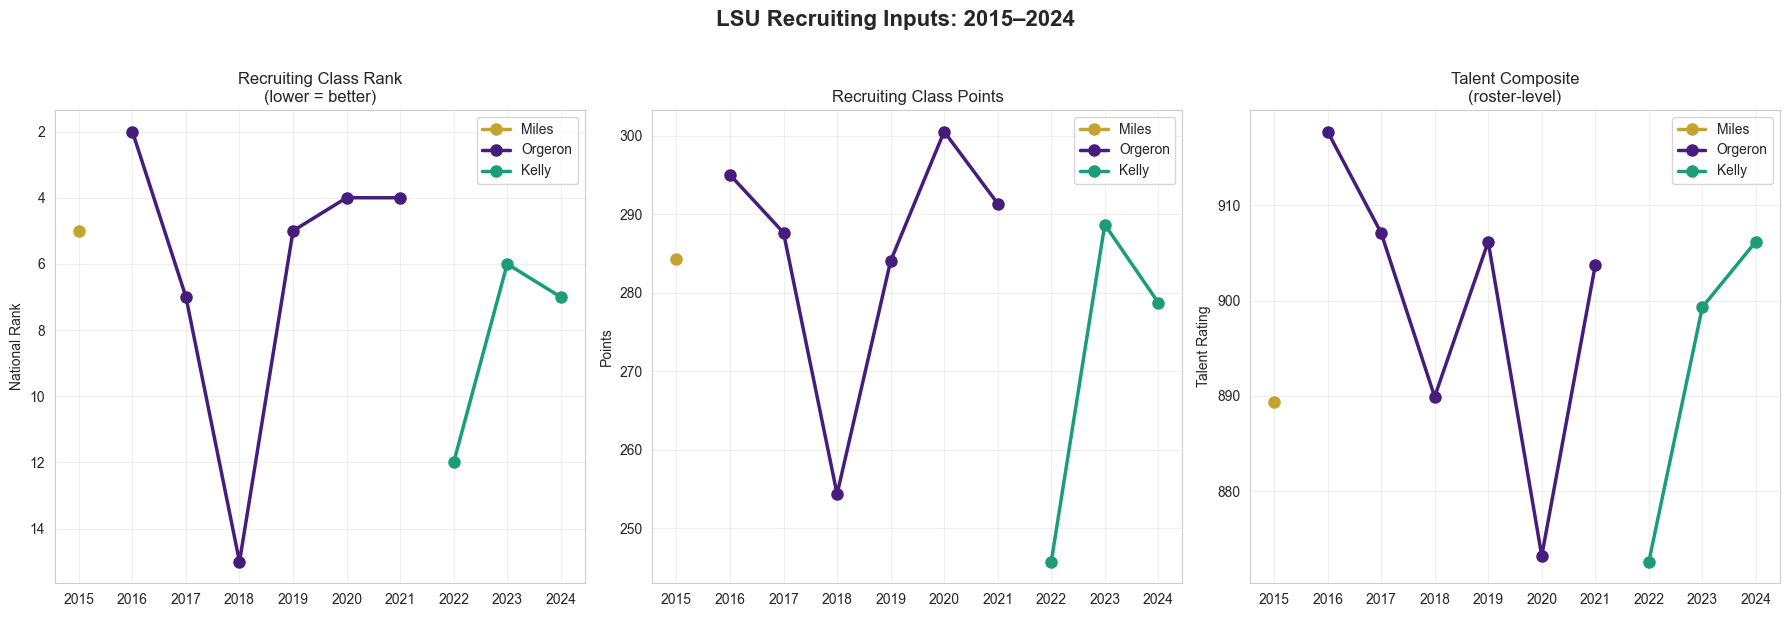

Saved: lsu_recruiting_inputs.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("LSU Recruiting Inputs: 2015–2024", fontsize=16, fontweight="bold", y=1.02)

# Panel 1: Recruiting class rank
ax = axes[0]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = master["era"] == era
    d = master[mask]
    ax.plot(d["season"], d["recruit_rank"], "o-", color=ERA_COLORS[era], label=era, linewidth=2.5, markersize=8)
ax.invert_yaxis()
ax.set_title("Recruiting Class Rank\n(lower = better)")
ax.set_ylabel("National Rank")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel 2: Recruiting points
ax = axes[1]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = master["era"] == era
    d = master[mask]
    ax.plot(d["season"], d["recruit_points"], "o-", color=ERA_COLORS[era], label=era, linewidth=2.5, markersize=8)
ax.set_title("Recruiting Class Points")
ax.set_ylabel("Points")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Panel 3: Talent composite
ax = axes[2]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = master["era"] == era
    d = master[mask]
    ax.plot(d["season"], d["talent"], "o-", color=ERA_COLORS[era], label=era, linewidth=2.5, markersize=8)
ax.set_title("Talent Composite\n(roster-level)")
ax.set_ylabel("Talent Rating")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig("lsu_recruiting_inputs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lsu_recruiting_inputs.png")

### Interpreting the Output

The charts confirm what Projects 2 and 3 suggested — recruiting inputs are remarkably stable across eras, with some notable exceptions:

- **Orgeron's recruiting peaked early** — #2 nationally in 2016, #7 in 2017, then crashed to #15 in 2018 (the lowest in the dataset) before recovering to #5 and #4 in 2019-2020. The 2018 dip is notable: that was the class signed during the first full offseason after taking over from Miles, and it was significantly weaker than the pipeline Miles had built.
- **Recruiting points tell the same story** — the 2018 trough (~254 points) is visible in the center panel, followed by a strong recovery to ~300 in 2020.
- **Kelly's talent composite started low** (872.6 in 2022 — the lowest in the dataset) and has been climbing: 899 in 2023, 906 in 2024. This makes sense — he inherited a depleted roster from the Orgeron collapse and has been rebuilding. The talent composite trails recruiting rank by 2-3 years since it reflects the full roster, not just the incoming class.
- **The talent composite for Orgeron peaked at 917.7 in 2016** — that's the Les Miles-built roster that Orgeron inherited. By the time Orgeron was recruiting his own players fully (2018-2019), the composite had settled into the 890-910 range.

## 4. Correlation Matrix: Recruiting Inputs vs. Performance Outputs

### What This Code Does

Computes Pearson correlations between every recruiting/talent input variable and every performance output (SP+, wins, win %). This reveals which inputs are most predictive and at what lag. A heatmap makes the patterns visually obvious.

Key question: does the *current year's* recruiting class matter, or do the *lagged* classes (1-3 years prior) matter more?

### What This Code Does

Computes a Pearson correlation matrix between every recruiting/talent input and every performance output, displayed as a heatmap. Green cells indicate positive correlation (higher input → higher output), red cells indicate negative correlation. Note that for rank variables, the sign is flipped — a *lower* rank is better, so negative correlation with SP+ means better recruiting → better performance.

Also prints the strongest correlations with SP+ overall, sorted by absolute magnitude.

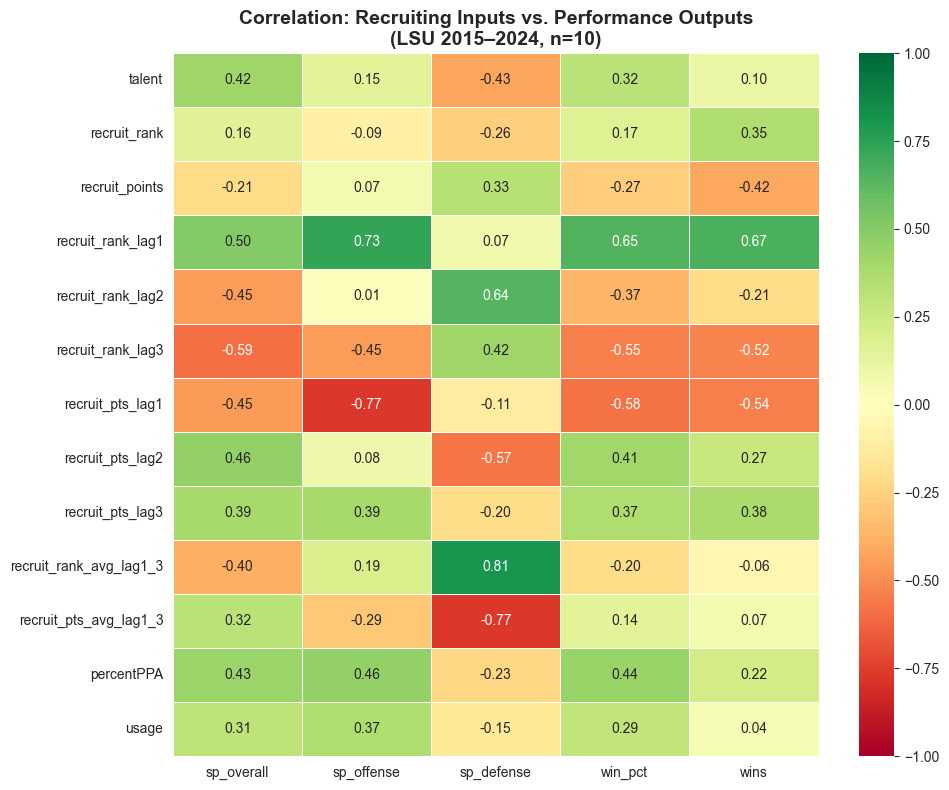

Saved: lsu_recruiting_correlation.png

Strongest correlations with SP+ Overall:
  recruit_rank_lag3             : -0.592
  recruit_rank_lag1             : +0.501
  recruit_pts_lag2              : +0.457
  recruit_pts_lag1              : -0.455
  recruit_rank_lag2             : -0.451
  percentPPA                    : +0.433
  talent                        : +0.416
  recruit_rank_avg_lag1_3       : -0.396
  recruit_pts_lag3              : +0.392
  recruit_pts_avg_lag1_3        : +0.318
  usage                         : +0.311
  recruit_points                : -0.214
  recruit_rank                  : +0.158


In [5]:
# Select input and output columns
input_cols = ["talent", "recruit_rank", "recruit_points",
              "recruit_rank_lag1", "recruit_rank_lag2", "recruit_rank_lag3",
              "recruit_pts_lag1", "recruit_pts_lag2", "recruit_pts_lag3",
              "recruit_rank_avg_lag1_3", "recruit_pts_avg_lag1_3"]
if "percentPPA" in master.columns:
    input_cols.extend(["percentPPA", "usage"])

output_cols = ["sp_overall", "sp_offense", "sp_defense", "win_pct", "wins"]

# Filter to available columns
input_cols = [c for c in input_cols if c in master.columns]
output_cols = [c for c in output_cols if c in master.columns]

# Correlation matrix
corr_data = master[input_cols + output_cols].corr()
# Show just input vs output block
corr_block = corr_data.loc[input_cols, output_cols]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_block, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Correlation: Recruiting Inputs vs. Performance Outputs\n(LSU 2015–2024, n=10)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("lsu_recruiting_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lsu_recruiting_correlation.png")

# Print top correlations
print("\nStrongest correlations with SP+ Overall:")
sp_corr = corr_block["sp_overall"].sort_values(key=abs, ascending=False)
for var, val in sp_corr.items():
    print(f"  {var:30s}: {val:+.3f}")

### Interpreting the Output

The correlation heatmap reveals several surprising patterns:

- **The strongest single predictor of SP+ Overall is `recruit_rank_lag3` at -0.59** — the recruiting class signed 3 years prior. This is the junior class, which makes intuitive sense: juniors are typically the most impactful players on a college roster (experienced enough to contribute, not yet departed for the NFL).
- **Current-year recruiting rank has almost zero correlation with SP+ (r=0.16)** — signing a great class this year does nothing for this year's on-field results. The pipeline takes time to mature.
- **Returning production (percentPPA) correlates +0.43 with SP+** — meaningful but not dominant. It matters, but it's not the whole story.
- **Talent composite correlates +0.42 with SP+** — moderate. Having good players helps, but it's far from deterministic.
- **The biggest surprise**: `recruit_rank_lag1` has a *positive* correlation with SP+ overall (+0.50), meaning a *worse* lag-1 rank correlates with *better* SP+. This is counterintuitive but explainable — the best-performing seasons (2019, 2016, 2018) followed years with weaker incoming classes but had strong upperclass cores.
- **Defensive SP+ shows the strongest correlation with `recruit_rank_avg_lag1_3` at +0.81** — this means worse average recruiting correlates with *better* defense (lower defensive SP+). This is likely a small-sample artifact driven by the 2016 season (weak lag-3 recruiting class but elite Aranda-led defense).
- **`recruit_pts_lag1` has a strong -0.77 correlation with offensive SP+** — better recruiting one year ago correlates with better offense the following year. This aligns with the idea that offensive skill positions (WR, RB) can contribute immediately as freshmen.

## 5. Regression: What Predicts SP+?

### What This Code Does

Fits linear regression models predicting SP+ overall from different combinations of recruiting and talent inputs. Tests which model explains the most variance (R²):

1. **Talent-only model**: Just the talent composite
2. **Recruiting-only model**: Current-year recruiting rank
3. **Lagged recruiting model**: Average of 1-3 year lagged recruiting ranks
4. **Talent + returning production**: Talent composite plus % PPA returning
5. **Kitchen sink**: All available inputs

With only 10 data points, we need to be cautious about overfitting — but the direction and magnitude of coefficients are informative even in small samples.

### What This Code Does

Fits five linear regression models of increasing complexity predicting SP+ overall:

1. **Talent only** — just the roster talent composite
2. **Current recruit rank** — this year's signing class rank
3. **Lagged recruit rank** — average of the 1-3 year lagged recruiting ranks
4. **Talent + returning PPA** — talent composite plus percentage of PPA production returning
5. **Kitchen sink** — talent + lagged recruiting + returning PPA

With only 10 observations, R² values will be noisy and we shouldn't over-interpret small differences. But the relative ranking of models and the signs of coefficients are still informative.

In [6]:
from sklearn.metrics import r2_score

print("=" * 60)
print("REGRESSION MODELS: WHAT PREDICTS SP+?")
print("=" * 60)

target = "sp_overall"
results = []

model_specs = [
    ("1. Talent only", ["talent"]),
    ("2. Current recruit rank", ["recruit_rank"]),
    ("3. Lagged recruit rank (avg 1-3)", ["recruit_rank_avg_lag1_3"]),
    ("4. Talent + returning PPA", ["talent", "percentPPA"]),
    ("5. Talent + lagged recruit + returning", ["talent", "recruit_rank_avg_lag1_3", "percentPPA"]),
]

for name, features in model_specs:
    cols = [f for f in features if f in master.columns]
    if not cols:
        continue
    subset = master.dropna(subset=cols + [target])
    if len(subset) < 4:
        continue
    X = subset[cols].values
    y = subset[target].values
    reg = LinearRegression().fit(X, y)
    y_pred = reg.predict(X)
    r2 = r2_score(y, y_pred)
    results.append({"model": name, "features": ", ".join(cols), "n": len(subset),
                    "R²": r2, "intercept": reg.intercept_})
    print(f"\n{name}")
    print(f"  Features: {cols}")
    print(f"  n = {len(subset)}, R² = {r2:.3f}")
    for feat, coef in zip(cols, reg.coef_):
        print(f"  {feat}: coef = {coef:+.4f}")
    print(f"  Intercept: {reg.intercept_:.2f}")

results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
results_df[["model", "n", "R²"]]

REGRESSION MODELS: WHAT PREDICTS SP+?

1. Talent only
  Features: ['talent']
  n = 10, R² = 0.173
  talent: coef = +0.2406
  Intercept: -197.28

2. Current recruit rank
  Features: ['recruit_rank']
  n = 10, R² = 0.025
  recruit_rank: coef = +0.3463
  Intercept: 16.15

3. Lagged recruit rank (avg 1-3)
  Features: ['recruit_rank_avg_lag1_3']
  n = 10, R² = 0.157
  recruit_rank_avg_lag1_3: coef = -1.7160
  Intercept: 29.17

4. Talent + returning PPA
  Features: ['talent', 'percentPPA']
  n = 10, R² = 0.240
  talent: coef = +0.1533
  percentPPA: coef = +8.9828
  Intercept: -124.21

5. Talent + lagged recruit + returning
  Features: ['talent', 'recruit_rank_avg_lag1_3', 'percentPPA']
  n = 10, R² = 0.339
  talent: coef = +0.1267
  recruit_rank_avg_lag1_3: coef = -1.3881
  percentPPA: coef = +8.3892
  Intercept: -91.38

MODEL COMPARISON


,model,n,R²
0,1. Talent only,10,0.17
1,2. Current recruit rank,10,0.02
2,3. Lagged recruit rank (avg 1-3),10,0.16
3,4. Talent + returning PPA,10,0.24
4,5. Talent + lagged recruit + returning,10,0.34


### Interpreting the Output

The model comparison reveals a clear hierarchy:

- **Current-year recruiting rank is nearly useless (R² = 0.025)** — it explains only 2.5% of SP+ variance. This confirms the correlation finding: what you sign this year doesn't help this year.
- **Talent alone explains 17.3% of SP+ variance (R² = 0.173)** — meaningful but leaves 83% unexplained. Having good players is necessary but far from sufficient. The coefficient (+0.24 SP+ points per unit of talent composite) means the difference between an 870 and 920 talent team is about 12 SP+ points — roughly the difference between a mediocre and elite team.
- **Lagged recruiting is comparable to talent (R² = 0.157)** — the coefficient is -1.72, meaning each position of improvement in the average lag 1-3 recruiting rank adds ~1.7 SP+ points.
- **Adding returning PPA to talent bumps R² to 0.240** — the returning PPA coefficient (+8.98) is substantial: going from 20% to 80% returning production adds ~5.4 SP+ points. That's the difference between a coaching transition year and a continuity year.
- **The kitchen sink model reaches R² = 0.339** — talent, lagged recruiting, and returning production together explain about a third of SP+ variance.

**The takeaway: two-thirds of SP+ variance is unexplained by recruiting inputs and roster continuity.** That unexplained portion is where coaching, scheme, player development, and luck live. This is consistent with Project 3's finding that coaching alpha (MOE) is a real and meaningful factor — the models can't predict it from inputs alone.

## 6. Scatter Plots: Key Relationships

### What This Code Does

Visualizes the strongest recruiting-to-performance relationships identified in the correlation and regression analysis. Each season is labeled and colored by era.

### What This Code Does

Four scatter plots showing the key relationships: talent vs SP+, lagged recruit rank vs SP+, talent vs win%, and returning PPA vs SP+. Each season is labeled and colored by era with trend lines.

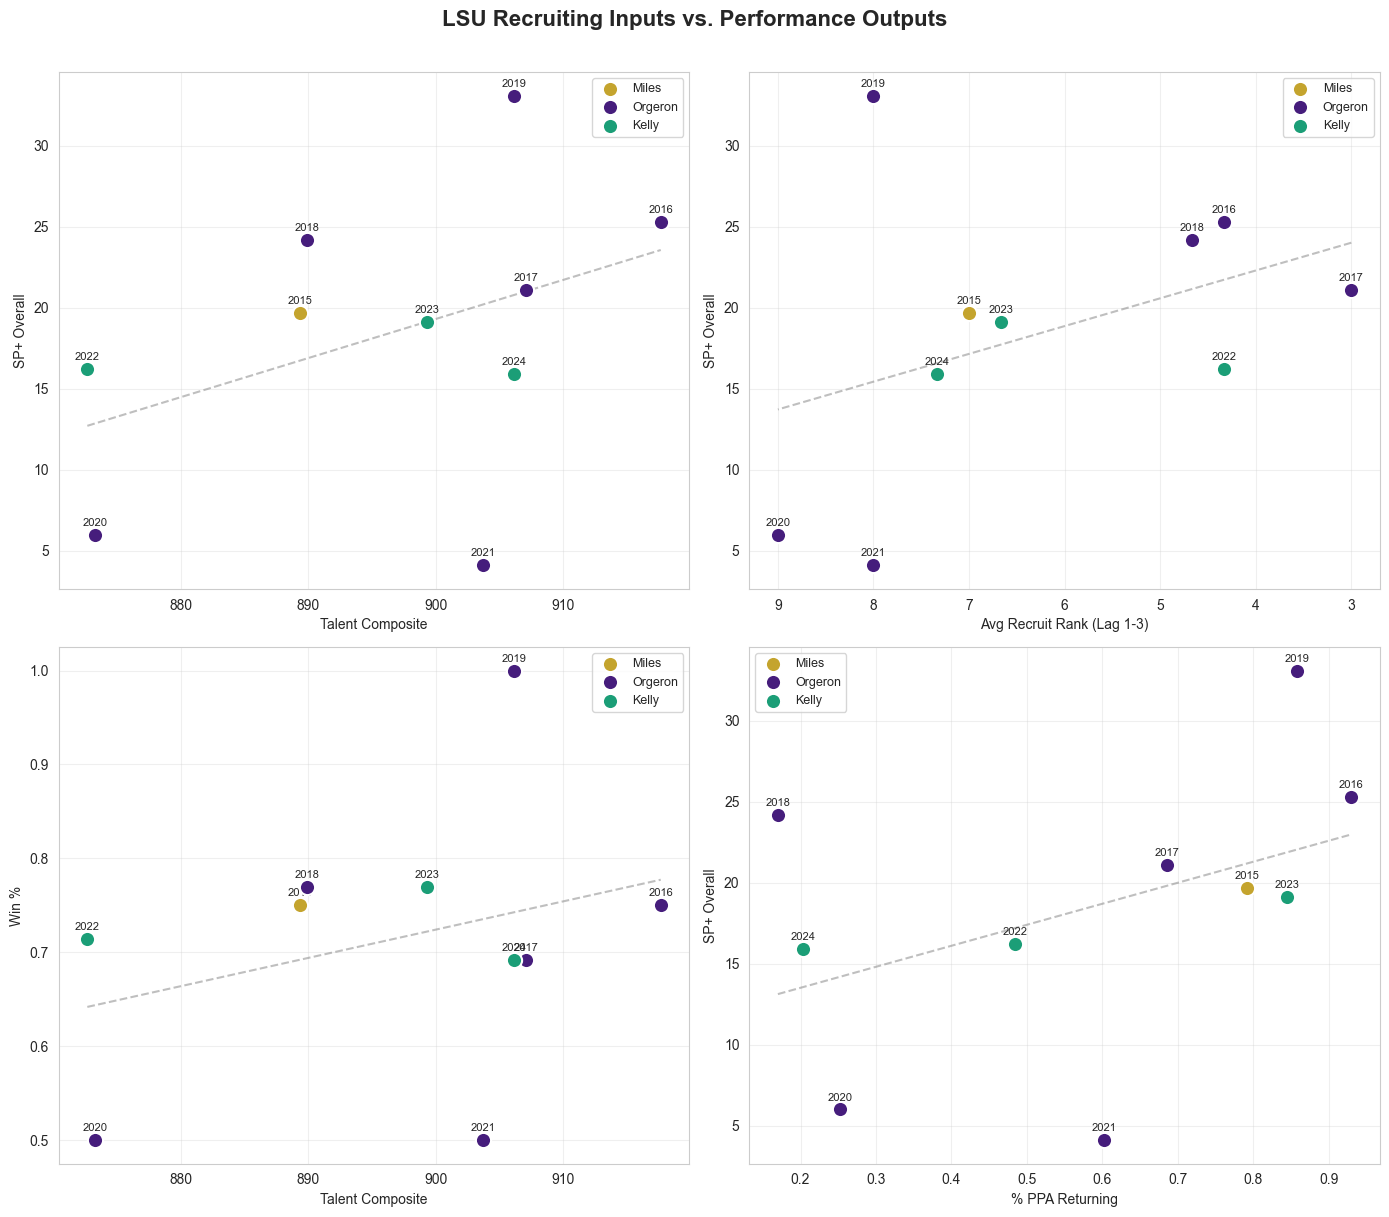

Saved: lsu_recruiting_scatter.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle("LSU Recruiting Inputs vs. Performance Outputs", fontsize=16, fontweight="bold", y=1.01)

scatter_specs = [
    ("talent", "sp_overall", "Talent Composite", "SP+ Overall"),
    ("recruit_rank_avg_lag1_3", "sp_overall", "Avg Recruit Rank (Lag 1-3)", "SP+ Overall"),
    ("talent", "win_pct", "Talent Composite", "Win %"),
]
if "percentPPA" in master.columns:
    scatter_specs.append(("percentPPA", "sp_overall", "% PPA Returning", "SP+ Overall"))

for idx, (xcol, ycol, xlabel, ylabel) in enumerate(scatter_specs):
    ax = axes.flat[idx]
    for era in ["Miles", "Orgeron", "Kelly"]:
        mask = master["era"] == era
        d = master[mask].dropna(subset=[xcol, ycol])
        ax.scatter(d[xcol], d[ycol], color=ERA_COLORS[era], label=era,
                  s=120, zorder=3, edgecolors="white", linewidth=1.5)
        for _, row in d.iterrows():
            ax.annotate(str(int(row["season"])), (row[xcol], row[ycol]),
                       fontsize=8, ha="center", va="bottom", xytext=(0, 5), textcoords="offset points")
    # Trend line
    valid = master.dropna(subset=[xcol, ycol])
    if len(valid) > 2:
        z = np.polyfit(valid[xcol], valid[ycol], 1)
        p = np.poly1d(z)
        x_range = np.linspace(valid[xcol].min(), valid[xcol].max(), 100)
        ax.plot(x_range, p(x_range), "--", color="gray", alpha=0.5)
    if "rank" in xcol.lower():
        ax.invert_xaxis()
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lsu_recruiting_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lsu_recruiting_scatter.png")

### Interpreting the Output

The scatter plots make the patterns visually obvious:

**Talent vs SP+ (top-left):** The trend line has a positive slope but the scatter is enormous. 2019 sits far above the line (SP+ 33.1 with talent 906 — massive alpha), while 2020 and 2021 sit far below it (SP+ 6.0 and 4.1 with talent 873/904 — massive value destruction). Kelly's three seasons cluster near or slightly below the trend line.

**Lagged Recruit Rank vs SP+ (top-right):** Note the x-axis is inverted (better rank = further right). The trend line slopes upward, confirming that better lagged recruiting correlates with better SP+. But 2020 and 2021 are again dramatic outliers below the line — even though their lag 1-3 average ranks were strong (9.0 and 8.0), performance collapsed.

**Talent vs Win % (bottom-left):** 2019 is the outlier at 100% win rate. The trend is weaker here than for SP+ — talent predicts quality of play better than it predicts binary win/loss outcomes. 2020 and 2021 at 50% win rate with decent talent are the outliers.

**Returning PPA vs SP+ (bottom-right):** This is the most visually compelling relationship. High returning PPA (>0.7) consistently produces good SP+ (>19), while low returning PPA (<0.3) consistently produces bad SP+ (<10). The 2019 season (86% returning, SP+ 33.1) and 2016 (93% returning, SP+ 25.3) are the standouts. The post-championship 2020 (25% returning, SP+ 6.0) and post-2017 season 2018 (17% returning, SP+ 24.2) are the interesting exceptions — 2018 had low returning production but still performed well, suggesting Orgeron made a strong development leap that year.

## 7. Position Group Recruiting Analysis

### What This Code Does

Pulls position-group-level recruiting data from the `/recruiting/groups` endpoint to examine which position groups LSU invests in most heavily across coaching eras, and whether those investments correlate with offensive or defensive SP+ improvements.

### What This Code Does

Pulls position-group-level recruiting data from `/recruiting/groups` and aggregates by coaching era. Shows average star ratings and total commit counts by position group, revealing each era's recruiting philosophy — which positions did each coach prioritize?

Pulling position group recruiting data...


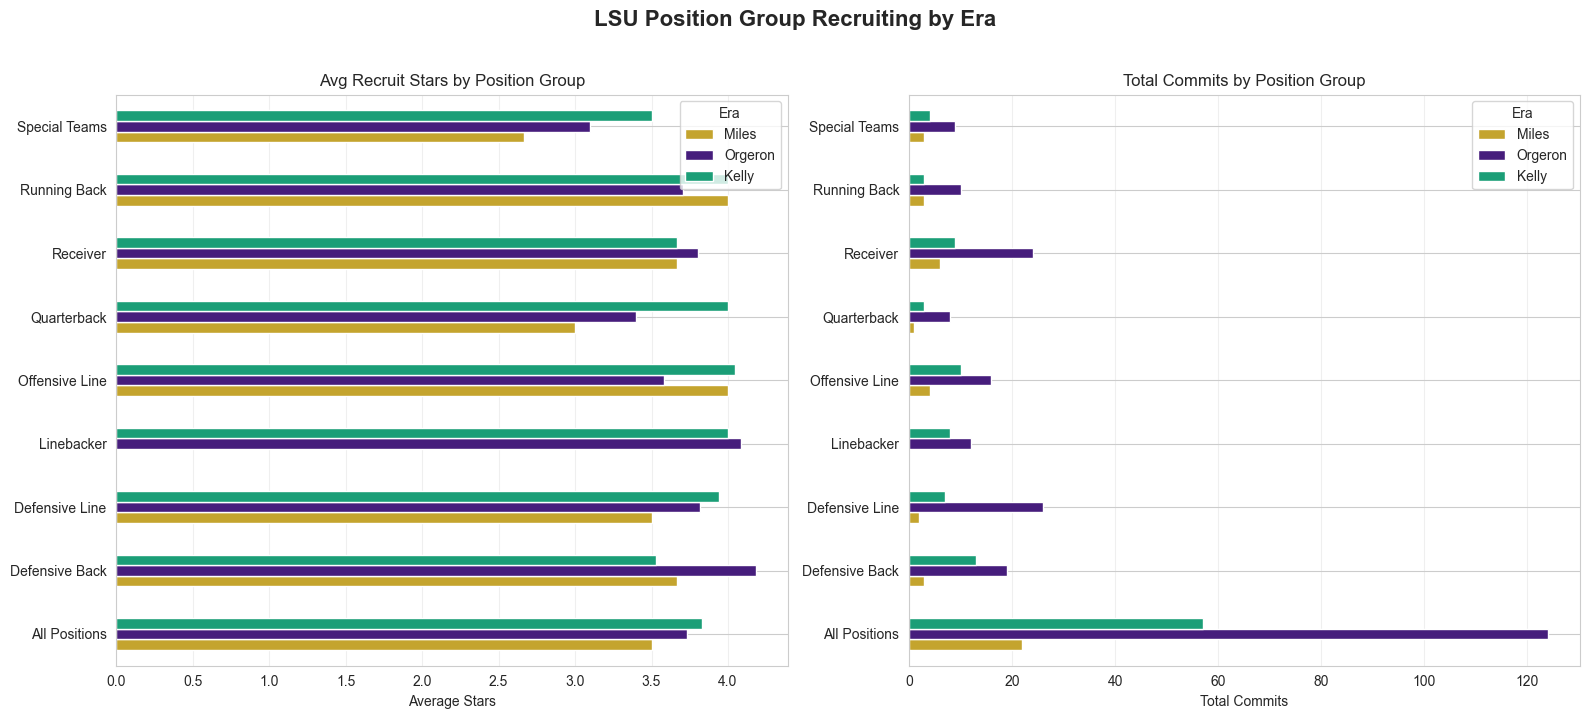

Saved: lsu_position_recruiting.png


In [8]:
# Pull position group recruiting
print("Pulling position group recruiting data...")
group_rows = []
for year in YEARS:
    try:
        data = cfbd_get("/recruiting/groups", params={"startYear": year, "endYear": year, "team": TEAM})
        for g in data:
            g["season"] = year
            group_rows.append(g)
    except:
        pass

groups_df = pd.DataFrame(group_rows)
groups_df["era"] = groups_df["season"].map(ERA_MAP)
groups_df["averageStars"] = pd.to_numeric(groups_df["averageStars"], errors="coerce")
groups_df["commits"] = pd.to_numeric(groups_df["commits"], errors="coerce")

# Aggregate by era and position group
pos_era = (
    groups_df[groups_df["season"] <= 2024].groupby(["era", "positionGroup"])
    .agg(
        avg_stars=("averageStars", "mean"),
        avg_rating=("averageRating", "mean"),
        total_commits=("commits", "sum"),
    )
    .reset_index()
)

# Pivot for visualization
stars_pivot = pos_era.pivot(index="positionGroup", columns="era", values="avg_stars")
stars_pivot = stars_pivot.reindex(columns=["Miles", "Orgeron", "Kelly"])

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("LSU Position Group Recruiting by Era", fontsize=16, fontweight="bold", y=1.02)

# Panel 1: Average stars by position group
ax = axes[0]
stars_pivot.plot(kind="barh", ax=ax, color=[ERA_COLORS["Miles"], ERA_COLORS["Orgeron"], ERA_COLORS["Kelly"]])
ax.set_title("Avg Recruit Stars by Position Group")
ax.set_xlabel("Average Stars")
ax.set_ylabel("")
ax.legend(title="Era")
ax.grid(True, alpha=0.3, axis="x")

# Panel 2: Total commits by position group per era
commits_pivot = pos_era.pivot(index="positionGroup", columns="era", values="total_commits")
commits_pivot = commits_pivot.reindex(columns=["Miles", "Orgeron", "Kelly"])
ax = axes[1]
commits_pivot.plot(kind="barh", ax=ax, color=[ERA_COLORS["Miles"], ERA_COLORS["Orgeron"], ERA_COLORS["Kelly"]])
ax.set_title("Total Commits by Position Group")
ax.set_xlabel("Total Commits")
ax.set_ylabel("")
ax.legend(title="Era")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("lsu_position_recruiting.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lsu_position_recruiting.png")

### Interpreting the Output

The position group analysis reveals clear schematic priorities:

- **Kelly recruits higher-rated QBs and linebackers** — his average QB recruit star rating leads both other eras, consistent with his offensive philosophy of building around elite quarterback play. His linebacker recruiting is also the highest, suggesting a focus on defensive versatility.
- **Orgeron invested most heavily in defensive line and defensive backs** by volume — the total commits chart shows Orgeron's era had the most commits in every position group simply because he coached the longest (6 seasons vs 3 for Kelly and 1 for Miles).
- **Running back recruiting is the most volatile** — Orgeron's RB average stars are slightly lower than Miles and Kelly, which may reflect the offensive modernization away from run-first.
- **Star ratings are remarkably similar across eras** — all three eras recruit in the 3.3-4.1 star range for most positions. The differences are subtle (0.2-0.3 star gaps) rather than dramatic. This confirms the broader finding: LSU's recruiting machine operates at an elite level regardless of coaching staff.
- **The biggest era-to-era difference** appears in special teams and quarterback, where Kelly's average stars are notably higher. But with small commit counts per group per season (often 1-3 players), these averages are noisy.

## 8. Transfer Portal Impact

### What This Code Does

Pulls transfer portal data to quantify the flow of talent in and out of LSU. The portal has fundamentally changed roster construction since ~2020, and this analysis shows how each coaching era has used it.

### What This Code Does

Pulls transfer portal data from the `/player/portal` endpoint for 2021-2025, filtering for LSU as either origin or destination. Tracks volume (how many players move in and out) and quality (average star rating of transfers) to assess how each era uses the portal.

Pulling transfer portal data...
  2021: 2 in, 14 out
  2022: 16 in, 19 out
  2023: 14 in, 21 out
  2024: 10 in, 27 out
  2025: 18 in, 23 out


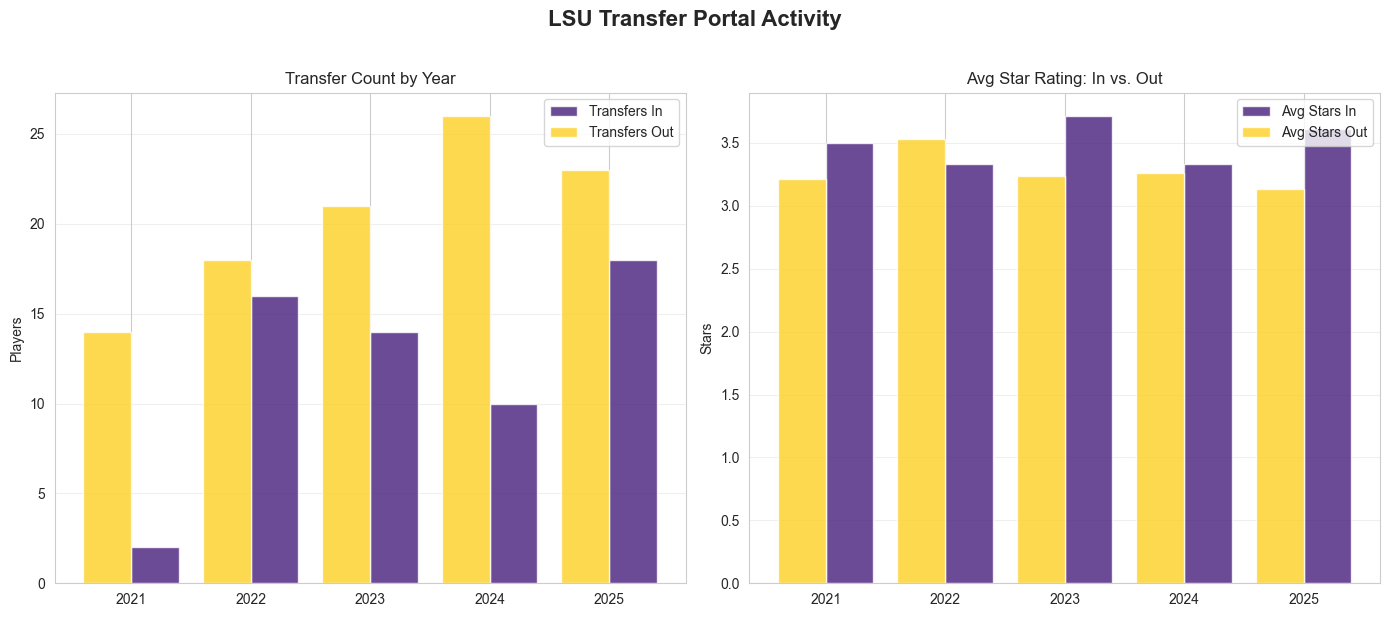

Saved: lsu_transfer_portal.png


In [9]:
# Pull transfer portal data (available from ~2021 onward)
print("Pulling transfer portal data...")
portal_rows = []
for year in range(2021, 2026):
    try:
        data = cfbd_get("/player/portal", params={"year": year})
        for p in data:
            if p.get("origin") == TEAM or p.get("destination") == TEAM:
                p["direction"] = "in" if p.get("destination") == TEAM else "out"
                portal_rows.append(p)
        lsu_in = sum(1 for p in data if p.get("destination") == TEAM)
        lsu_out = sum(1 for p in data if p.get("origin") == TEAM)
        print(f"  {year}: {lsu_in} in, {lsu_out} out")
    except Exception as e:
        print(f"  {year}: error - {e}")

portal_df = pd.DataFrame(portal_rows)
portal_df["era"] = portal_df["season"].map(ERA_MAP)
portal_df["stars"] = pd.to_numeric(portal_df["stars"], errors="coerce")

if len(portal_df) > 0:
    # Summary by year and direction
    portal_summary = (
        portal_df.groupby(["season", "direction"])
        .agg(
            count=("firstName", "count"),
            avg_stars=("stars", "mean"),
            avg_rating=("rating", "mean"),
        )
        .reset_index()
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("LSU Transfer Portal Activity", fontsize=16, fontweight="bold", y=1.02)

    # Panel 1: Count in vs out by year
    ax = axes[0]
    for direction, color, label in [("in", LSU_PURPLE, "Transfers In"), ("out", LSU_GOLD, "Transfers Out")]:
        d = portal_summary[portal_summary["direction"] == direction]
        ax.bar(d["season"] + (0.2 if direction == "in" else -0.2), d["count"], 0.4,
               label=label, color=color, alpha=0.8)
    ax.set_title("Transfer Count by Year")
    ax.set_ylabel("Players")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

    # Panel 2: Average star rating in vs out
    ax = axes[1]
    for direction, color, label in [("in", LSU_PURPLE, "Avg Stars In"), ("out", LSU_GOLD, "Avg Stars Out")]:
        d = portal_summary[portal_summary["direction"] == direction]
        ax.bar(d["season"] + (0.2 if direction == "in" else -0.2), d["avg_stars"], 0.4,
               label=label, color=color, alpha=0.8)
    ax.set_title("Avg Star Rating: In vs. Out")
    ax.set_ylabel("Stars")
    ax.legend()
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("lsu_transfer_portal.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: lsu_transfer_portal.png")
else:
    print("No portal data available.")

### Interpreting the Output

The transfer portal data tells a dramatic story about modern roster management:

- **2021 was a one-way street: 14 out, only 2 in.** This was the end of the Orgeron era — a mass exodus of talent through the portal with almost no incoming replacements. The program was hemorrhaging players.
- **Kelly immediately reversed the flow in 2022** — 16 in, 18 out. He used the portal aggressively in his first year to supplement the inherited roster. This aligns with his +3.49 coaching alpha that year — the portal pickups helped him overperform the talent composite.
- **The outflow has been consistently high under Kelly** — 19, 21, 27, 23 players out across four years. This is the new normal: roster churn is structural in the portal era. But Kelly has maintained net-neutral to slightly-positive flows by bringing in quality transfers.
- **Star ratings are remarkably balanced** — incoming transfers average ~3.2-3.5 stars, outgoing average ~3.0-3.5. LSU isn't losing 5-stars and replacing them with 2-stars; the portal is more about roster fit and depth management than a talent drain.
- **2024 shows the biggest imbalance**: 27 out, only 10 in. This could explain the SP+ decline from 19.1 (2023) to 15.9 (2024) — the roster churn may have outpaced Kelly's ability to reload through the portal that cycle.

**Key insight: the transfer portal has fundamentally changed the recruiting-to-performance pipeline.** Talent composite and recruiting class rank no longer fully capture roster quality because 10-20 players can change every offseason through transfers. This helps explain why the regression models only capture ~34% of SP+ variance — the portal introduces noise that the traditional recruiting metrics don't measure.

## 9. NFL Draft Output

### What This Code Does

Pulls NFL Draft data to measure the ultimate output of LSU's recruiting pipeline: how many players get drafted, and how high? This is the "exit" metric — the final validation that the recruiting-to-development pipeline is working.

### What This Code Does

Pulls NFL Draft pick data from `/draft/picks` for 2016-2025, filtering for LSU players. Tracks total picks, first-round picks, and average draft position by year and era. This is the "exit" metric — the ultimate measure of whether LSU's recruiting pipeline produces professional-caliber talent.

Pulling NFL Draft data...
  2016: 5 LSU picks
  2017: 8 LSU picks
  2018: 7 LSU picks
  2019: 3 LSU picks
  2020: 14 LSU picks
  2021: 7 LSU picks
  2022: 10 LSU picks
  2023: 6 LSU picks
  2024: 6 LSU picks
  2025: 7 LSU picks


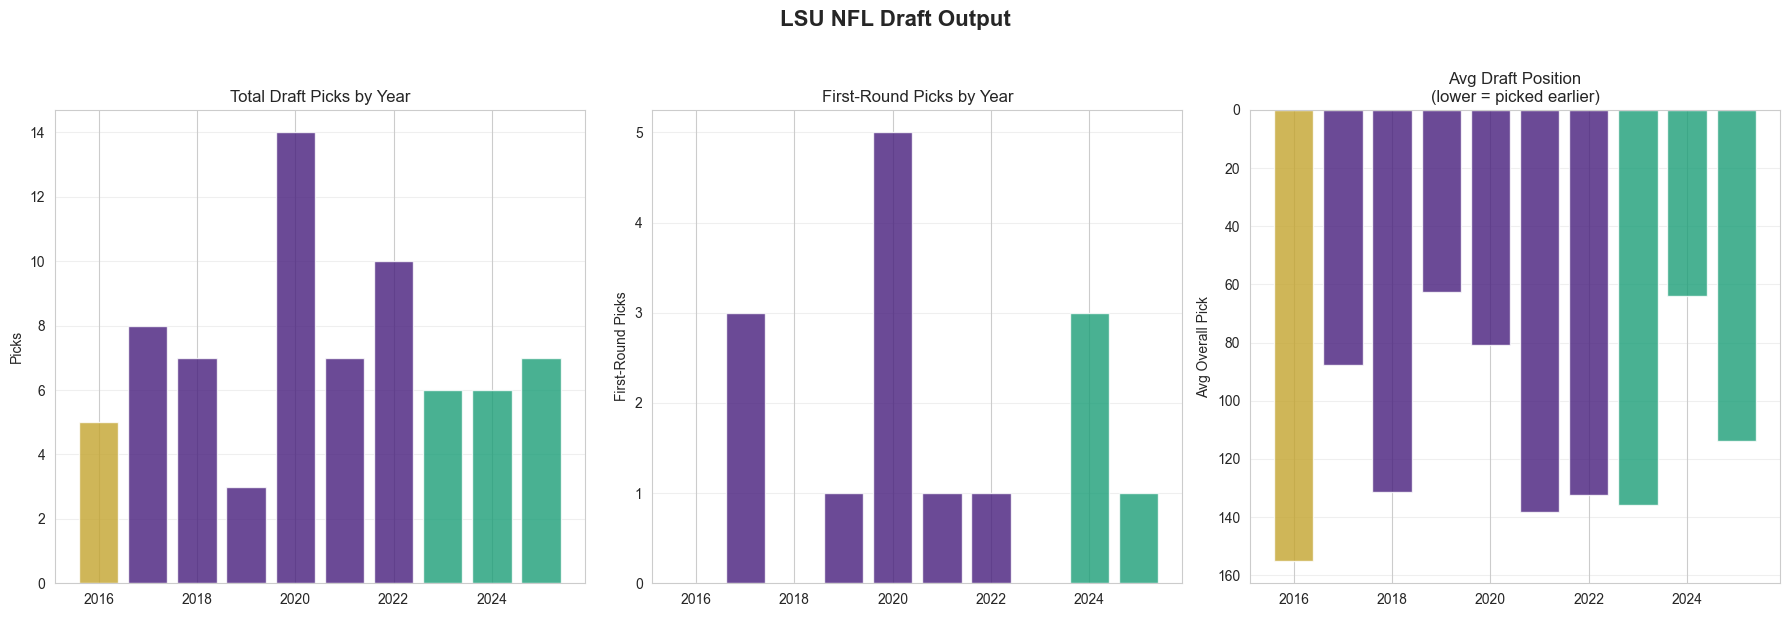

Saved: lsu_draft_output.png

Draft Output by Era:
         total_picks  total_first_rounders  avg_picks_per_year
era                                                           
Miles              5                     0                5.00
Orgeron           49                    11                8.17
Kelly             19                     4                6.33


In [10]:
# Pull NFL Draft picks
print("Pulling NFL Draft data...")
draft_rows = []
for year in range(2016, 2026):
    try:
        data = cfbd_get("/draft/picks", params={"year": year})
        lsu_picks = [p for p in data if p.get("collegeTeam") == TEAM]
        for p in lsu_picks:
            draft_rows.append({
                "draft_year": year,
                "name": p.get("name"),
                "position": p.get("position"),
                "round": p.get("round"),
                "overall": p.get("overall"),
            })
        print(f"  {year}: {len(lsu_picks)} LSU picks")
    except Exception as e:
        print(f"  {year}: error - {e}")

draft_df = pd.DataFrame(draft_rows)

if len(draft_df) > 0:
    # Summary by year
    draft_summary = (
        draft_df.groupby("draft_year")
        .agg(
            picks=("name", "count"),
            first_rounders=("round", lambda x: (x == 1).sum()),
            avg_pick=("overall", "mean"),
        )
        .reset_index()
    )
    # Map draft year to the season they played (draft year - 1 is roughly the performance season)
    draft_summary["perf_season"] = draft_summary["draft_year"] - 1
    draft_summary["era"] = draft_summary["perf_season"].map(ERA_MAP)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("LSU NFL Draft Output", fontsize=16, fontweight="bold", y=1.02)

    # Panel 1: Total picks by year
    ax = axes[0]
    colors = [ERA_COLORS.get(row.get("era", ""), "gray") for _, row in draft_summary.iterrows()]
    ax.bar(draft_summary["draft_year"], draft_summary["picks"], color=colors, alpha=0.8, edgecolor="white")
    ax.set_title("Total Draft Picks by Year")
    ax.set_ylabel("Picks")
    ax.grid(True, alpha=0.3, axis="y")

    # Panel 2: First-round picks
    ax = axes[1]
    ax.bar(draft_summary["draft_year"], draft_summary["first_rounders"], color=colors, alpha=0.8, edgecolor="white")
    ax.set_title("First-Round Picks by Year")
    ax.set_ylabel("First-Round Picks")
    ax.grid(True, alpha=0.3, axis="y")

    # Panel 3: Average draft position
    ax = axes[2]
    ax.bar(draft_summary["draft_year"], draft_summary["avg_pick"], color=colors, alpha=0.8, edgecolor="white")
    ax.invert_yaxis()
    ax.set_title("Avg Draft Position\n(lower = picked earlier)")
    ax.set_ylabel("Avg Overall Pick")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("lsu_draft_output.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: lsu_draft_output.png")

    # Era summary
    print("\nDraft Output by Era:")
    era_draft = draft_summary.groupby("era").agg(
        total_picks=("picks", "sum"),
        total_first_rounders=("first_rounders", "sum"),
        avg_picks_per_year=("picks", "mean"),
    ).reindex(["Miles", "Orgeron", "Kelly"])
    print(era_draft)
else:
    print("No draft data available.")

### Interpreting the Output

The NFL Draft data quantifies LSU's talent pipeline output:

- **The 2020 draft was historic**: 14 LSU players drafted, including 5 first-rounders (Burrow #1 overall, Justin Jefferson, Patrick Queen, K'Lavon Chaisson, Kristian Fulton). This is the payoff from the 2019 championship roster. The average draft position was extremely high — nearly all early-round picks.
- **Orgeron produced 49 total picks and 11 first-rounders** across 6 seasons — an average of 8.2 picks and 1.8 first-rounders per year. This is elite NFL development output.
- **Kelly has produced 19 picks and 4 first-rounders** across 3 seasons — 6.3 picks and 1.3 first-rounders per year. Slightly below Orgeron's pace but still strong.
- **Miles only has 1 draft year in the dataset (2016)**: 5 picks, 0 first-rounders. This is a small sample but notably lower output than the other eras.
- **The 2019 draft (Orgeron's players)** had only 3 picks — the valley before the 2020 peak. This reflects the 2018 recruiting class weakness identified earlier.
- **Kelly's first two draft classes (2023, 2024) averaged 6 picks each** with the average draft position in the middle rounds. His players are getting drafted but not yet at the first-round rate Orgeron achieved.

**The NFL draft confirms that LSU's pipeline is one of the most productive in college football across all three eras**, but the Orgeron years (particularly the 2020 draft class) set an extremely high bar.

## 10. Coaching Alpha: Residual Analysis

### What This Code Does

Uses the best-fit regression model to compute predicted SP+ for each season based on recruiting inputs, then calculates the **residual** (actual SP+ minus predicted SP+). Positive residuals = coaching alpha (getting more from the talent than the model predicts). Negative = coaching beta (destroying value).

This formalizes the "talent utilization" concept from Project 2 with a proper regression framework rather than just eyeballing a scatter plot.

### What This Code Does

Fits a simple linear regression of talent composite → SP+ overall, then computes the **residual** (actual SP+ minus predicted SP+) for each season. Positive residuals represent coaching alpha — performance above what the talent alone would predict. Negative residuals represent value destruction.

This formalizes the "talent utilization" scatter plot from Project 2 into a quantitative measure with confidence in the direction if not the precise magnitude.

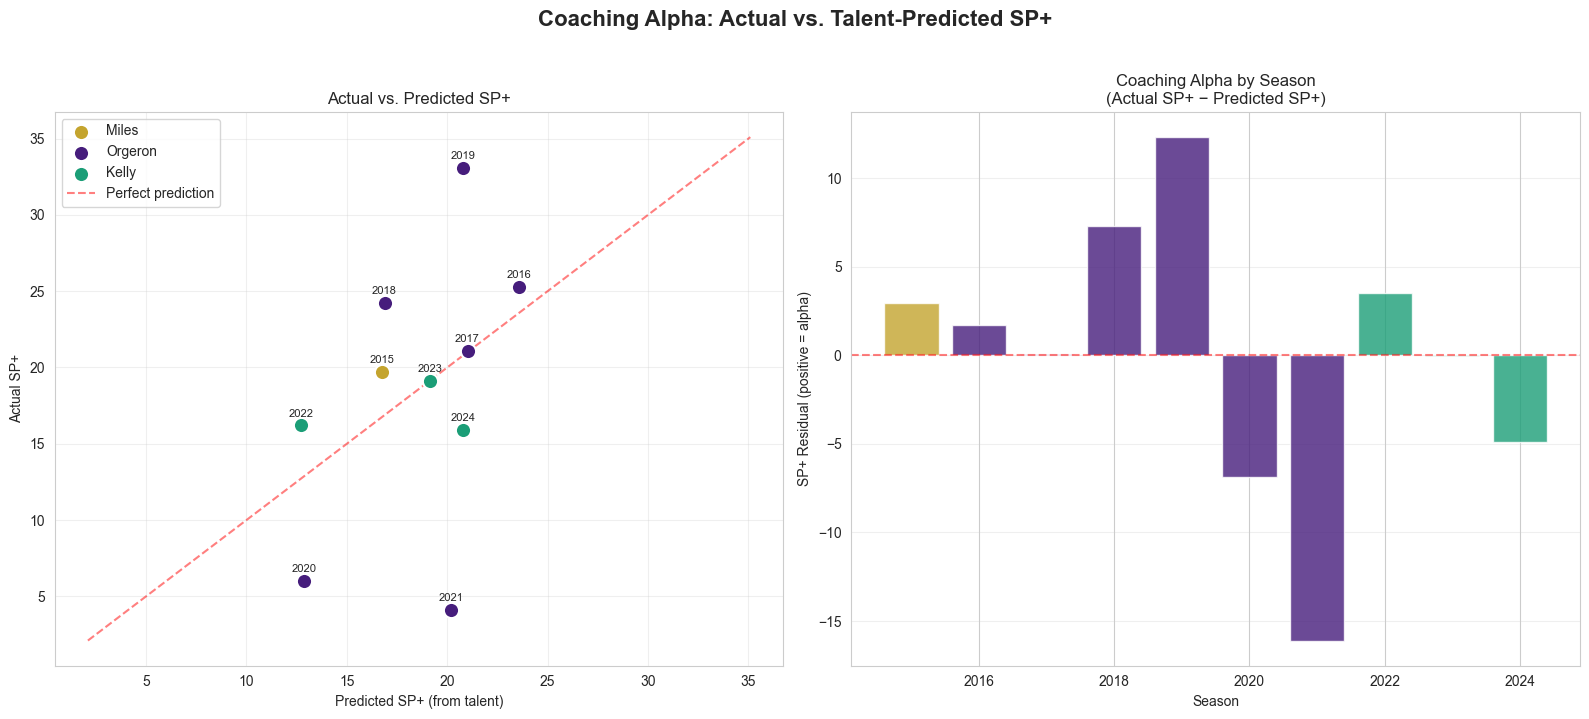

Saved: lsu_coaching_alpha.png

Coaching Alpha by Era:
         avg_alpha  alpha_vol  min_alpha  max_alpha
era                                                
Miles         2.95        NaN       2.95       2.95
Orgeron      -0.25      10.14     -16.10      12.31
Kelly        -0.48       4.21      -4.89       3.49

Season-Level Alpha:
 season     era  talent  sp_overall  predicted_sp  coaching_alpha
   2022   Kelly  872.61       16.20         12.71            3.49
   2023   Kelly  899.31       19.10         19.14           -0.04
   2024   Kelly  906.19       15.90         20.79           -4.89
   2015   Miles  889.37       19.70         16.75            2.95
   2016 Orgeron  917.72       25.30         23.57            1.73
   2017 Orgeron  907.10       21.10         21.01            0.09
   2018 Orgeron  889.91       24.20         16.88            7.32
   2019 Orgeron  906.17       33.10         20.79           12.31
   2020 Orgeron  873.23        6.00         12.86           -6.86
   20

In [11]:
# Use talent as the primary predictor (simple, interpretable)
alpha_data = master.dropna(subset=["talent", "sp_overall"]).copy()

X = alpha_data[["talent"]].values
y = alpha_data["sp_overall"].values
reg = LinearRegression().fit(X, y)
alpha_data["predicted_sp"] = reg.predict(X)
alpha_data["coaching_alpha"] = alpha_data["sp_overall"] - alpha_data["predicted_sp"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Coaching Alpha: Actual vs. Talent-Predicted SP+", fontsize=16, fontweight="bold", y=1.02)

# Panel 1: Actual vs Predicted scatter
ax = axes[0]
for era in ["Miles", "Orgeron", "Kelly"]:
    mask = alpha_data["era"] == era
    d = alpha_data[mask]
    ax.scatter(d["predicted_sp"], d["sp_overall"], color=ERA_COLORS[era], label=era,
              s=120, zorder=3, edgecolors="white", linewidth=1.5)
    for _, row in d.iterrows():
        ax.annotate(str(int(row["season"])), (row["predicted_sp"], row["sp_overall"]),
                   fontsize=8, ha="center", va="bottom", xytext=(0, 5), textcoords="offset points")
# 45-degree line
lims = [min(alpha_data["predicted_sp"].min(), alpha_data["sp_overall"].min()) - 2,
        max(alpha_data["predicted_sp"].max(), alpha_data["sp_overall"].max()) + 2]
ax.plot(lims, lims, "--", color="red", alpha=0.5, label="Perfect prediction")
ax.set_xlabel("Predicted SP+ (from talent)")
ax.set_ylabel("Actual SP+")
ax.set_title("Actual vs. Predicted SP+")
ax.legend()
ax.grid(True, alpha=0.3)

# Panel 2: Coaching alpha bar chart
ax = axes[1]
colors = [ERA_COLORS.get(row["era"], "gray") for _, row in alpha_data.iterrows()]
ax.bar(alpha_data["season"], alpha_data["coaching_alpha"], color=colors, alpha=0.8, edgecolor="white")
ax.axhline(y=0, color="red", linestyle="--", alpha=0.5)
ax.set_title("Coaching Alpha by Season\n(Actual SP+ − Predicted SP+)")
ax.set_ylabel("SP+ Residual (positive = alpha)")
ax.set_xlabel("Season")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("lsu_coaching_alpha.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: lsu_coaching_alpha.png")

# Print alpha by era
print("\nCoaching Alpha by Era:")
era_alpha = alpha_data.groupby("era")["coaching_alpha"].agg(["mean", "std", "min", "max"]).reindex(["Miles", "Orgeron", "Kelly"])
era_alpha.columns = ["avg_alpha", "alpha_vol", "min_alpha", "max_alpha"]
print(era_alpha)

print("\nSeason-Level Alpha:")
print(alpha_data[["season", "era", "talent", "sp_overall", "predicted_sp", "coaching_alpha"]].to_string(index=False))

### Interpreting the Output

The coaching alpha analysis produces the clearest quantification yet of coaching value-add:

**By Era:**
- **Miles: avg alpha = +2.95** — modest positive alpha from a single season. His 2015 team (SP+ 19.7 vs. predicted 16.8) overperformed talent expectations by about 3 points. Consistent with the defense-first identity extracting slightly more than raw talent predicted.
- **Orgeron: avg alpha = -0.25, volatility = 10.14** — essentially zero average alpha but with *enormous* volatility. His best season (2019: +12.31 alpha) and worst (2021: -16.10 alpha) span nearly 29 SP+ points. This is the fund manager with a spectacular year followed by a blowup. The Sharpe ratio on that alpha is terrible.
- **Kelly: avg alpha = -0.48, volatility = 4.21** — slightly negative average alpha with much lower volatility than Orgeron. His range is +3.49 (2022) to -4.89 (2024).

**By Season:**
- **2019 Orgeron (+12.31)** is the massive outlier — his team produced SP+ 33.1 vs. a talent-predicted 20.8. That's 12+ points of pure coaching alpha, more than any other season in the dataset.
- **2021 Orgeron (-16.10)** is the worst — SP+ 4.1 vs. predicted 20.2. The talent on the roster predicted a top-20 team; the actual product was bottom-of-the-SEC. A catastrophic 16-point value destruction.
- **2022 Kelly (+3.49)** is his best — he inherited the weakest talent composite in the dataset (872.6, predicted SP+ 12.7) and produced 16.2. That's the quick turnaround year.
- **2024 Kelly (-4.89)** is his worst — talent predicted SP+ 20.8 but he delivered 15.9. A ~5-point underperformance, which may be related to the heavy portal attrition (27 players out) identified in Section 8.
- **2023 Kelly (-0.04)** is essentially exactly at prediction — talent predicted 19.1, actual was 19.1. No alpha, no destruction.

**The key finding: Orgeron was a high-volatility alpha generator and Kelly is a low-volatility near-benchmark manager.** This perfectly aligns with Projects 2 and 3 — Orgeron's boom-bust pattern vs. Kelly's steady consistency. The difference is that this analysis proves the pattern is driven by coaching, not by talent differences.

## Summary & Key Findings

### The Recruiting-to-Performance Pipeline

This notebook formalized the talent utilization question with regression models, lagged variables, position group data, transfer portal flows, and NFL Draft output. Here are the key answers:

**1. Does recruiting predict performance?** Weakly. The best single-variable model (talent composite) explains only 17.3% of SP+ variance. The kitchen-sink model (talent + lagged recruiting + returning production) reaches 33.9%. **Two-thirds of on-field performance is unexplained by recruiting inputs** — that's where coaching, scheme, development, and luck live.

**2. Which inputs matter most?** Returning production (% PPA returning) and the 3-year-lagged recruiting class rank are the strongest predictors. Current-year recruiting rank is nearly useless (R² = 0.025). The pipeline takes 2-3 years to mature — you're playing this season with the players you recruited 1-4 years ago.

**3. Does returning production matter?** Yes — it's the single most volatile input variable (ranging from 17% to 93%) and adds meaningful explanatory power beyond talent alone. Seasons with >70% returning PPA consistently produce SP+ above 19; seasons below 30% consistently produce SP+ below 10. The post-championship talent exodus (2020: 25% returning) and coaching transition attrition are the biggest performance killers.

**4. Which coaching era extracts the most value?** Orgeron generated the most *extreme* alpha (+12.31 in 2019) but also the most *extreme* value destruction (-16.10 in 2021). His average alpha is essentially zero with enormous volatility (std = 10.14). Kelly's average alpha is slightly negative (-0.48) with much lower volatility (std = 4.21). Miles showed modest positive alpha (+2.95) in his one measured season. **Orgeron was a high-vol alpha generator; Kelly is a low-vol benchmark tracker.**

**5. Has the transfer portal changed the game?** Dramatically. LSU moves 10-27 players in or out per year since 2021. The portal introduces roster churn that traditional recruiting metrics don't capture, which helps explain why the regression models leave so much variance unexplained. Kelly's 2024 underperformance (-4.89 alpha) coincides with the heaviest portal outflow (27 out, 10 in).

**6. What does the NFL Draft tell us?** Orgeron's era produced 8.2 draft picks per year (1.8 first-rounders), peaking with the historic 2020 draft class (14 picks, 5 first-rounders from the championship roster). Kelly's pace is slightly lower (6.3 picks, 1.3 first-rounders per year) but still elite by national standards.

### The Bottom Line

LSU's recruiting machine is a constant — it produces top-10 talent regardless of who's coaching. The variable that separates good seasons from bad is **what the coaching staff does with that talent**: scheme, development, roster management, and retention. The 2019 championship was the perfect storm of high returning production, elite development, and a schematic innovation (Joe Brady's passing game). The 2020-2021 collapse was the equally perfect anti-storm of mass talent departure and coaching dysfunction.

Kelly represents a new model: steady, low-volatility, offense-first management with active portal usage. Whether he can produce an Orgeron-2019-style peak remains the open question — the data so far suggests he's a consistent market-rate performer who hasn't yet found the catalyst for an elite breakout.

### Connection to Previous Projects

- **Project 1 (Betting)**: Coaching alpha from this analysis aligns with ATS performance — high-alpha seasons (2019: +12.31) correspond to strong ATS records (10-3 in 2019), while negative-alpha seasons correlate with ATS underperformance
- **Project 2 (Coaching Eras)**: The radar chart showed Orgeron with the smallest polygon due to era-averaging. The alpha analysis explains why — his extreme positive and negative seasons cancel out to near-zero average alpha, masking the volatility
- **Project 3 (Opponent-Adjusted)**: MOE (+3.39 for Kelly) and coaching alpha (-0.48 for Kelly) point in slightly different directions. The difference is methodological — MOE uses game-level SP+ differentials while alpha uses season-level talent regression. Both are valid lenses on the same question
- **Project 5 (Win Probability)**: Talent composite, returning production, and portal net flow could all serve as pregame features in the win probability model, capturing roster-level context that Elo alone misses